In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy

## Import a mapping between recurrence and wind speed

In [2]:
local_folder_path = r'C:\YOUR\PATH\TO\WEUQ RESULTS (FORMATTED AS DISTINCT FOLDERS/WIND SPEED)'


hazard_data_path = os.path.normpath(os.path.join(local_folder_path,'..','Discretized_mp_v4.xlsx'))
hazard_data = pd.read_excel(hazard_data_path, index_col = 0 , header = [0,1])['MP45'].iloc[:,0:2]

MRI_data = dict(zip(hazard_data.iloc[:,0],hazard_data.iloc[:,1]))
MRI_data

{19: 56.38094567407204,
 27: 65.49786454902836,
 39: 74.6147834239847,
 59: 83.73170229894103,
 92: 92.84862117389737,
 149: 101.9655400488537,
 249: 111.08245892381,
 427: 120.1993777987663,
 753: 129.3162966737227,
 1367: 138.433215548679,
 2548: 147.5501344236353,
 4879: 156.6670532985917,
 9585: 165.783972173548,
 19316: 174.9008910485043,
 39909: 184.0178099234607,
 84503: 193.134728798417,
 183298: 202.2516476733733,
 407160: 211.3685665483297}

In [3]:
# Additional MSA inputs : 
MRI_data['MSA 2451'] = 179.459350485983
MRI_data['MSA 2482'] = 181.738580204722
MRI_data['MSA 2420'] = 177.180120767244
MRI_data['MSA 2544'] = 186.2970396422
MRI_data['MSA 2669'] = 195.413958517156

## Import the results

In [4]:
# Find the directory to the results :
results_dir = os.path.normpath(local_folder_path)
folders = [os.path.join(results_dir,x) for x in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir,x))]

In [5]:
filename_keyword = 'response'

# Extract raw results : 
simulation_results = pd.DataFrame()
raw_simulation_results = {}

for folder in folders : 
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder,f))]
    relevant_file = [f for f in files if filename_keyword in f]
    file = folder.split("\\")[-1]

    try :    
        file_dir = f"{os.path.join(folder,relevant_file[0])}"
        
        # Keep only PID columns :
        col_keyword = 'PID'

        df = pd.read_csv(file_dir, index_col = 0)
        cols_keep = [x for x in df.columns if col_keyword in x]
        df = df[cols_keep]
        
        data_series = df.max(axis=1)*100 # convert raw values to percentage 
        
        
        #wnd_speed = MRI_data[]
        
        if 'MSA' not in file :  
            file = int(file)        
            
        wnd_speed = MRI_data[file]
            
        data_series.name = float(f"{wnd_speed:.02f}")
        
        simulation_results = pd.concat([simulation_results,data_series],axis = 1)
        raw_simulation_results[wnd_speed] = df
        
    except : 
        continue     

simulation_results.sort_index(axis=1,inplace = True)
display(simulation_results)

,56.38,65.50,74.61,83.73,92.85,101.97,111.08,120.20,129.32,138.43,...,165.78,174.90,177.18,179.46,181.74,184.02,186.30,193.13,195.41,202.25
1,0.068868,0.102066,0.102827,0.112475,0.193712,0.184994,0.296535,0.302851,0.377747,0.438715,...,0.812488,0.979181,1.317520,1.89317,1.14006,4.22150,1.47718,20.65270,20.3817,20.0789
2,0.060294,0.080681,0.108648,0.131263,0.151165,0.209212,0.261959,0.371884,0.363538,0.500508,...,0.726926,1.079500,1.160090,20.48440,92.82440,1.34335,1.72470,2.68757,20.5376,20.0950
3,0.079255,0.074956,0.135337,0.142312,0.172469,0.207897,0.227310,0.264578,0.315444,0.461886,...,0.794885,1.668430,1.733540,1.34184,1.61090,5.37465,20.28340,1.94886,20.4685,20.3895
4,0.051465,0.073998,0.142958,0.158074,0.160955,0.199060,0.214596,0.277465,0.436968,0.452833,...,0.735592,0.885654,0.735225,2.31665,2.43475,20.28370,20.43360,2.57934,20.8443,20.9330
5,0.057420,0.077602,0.093555,0.191814,0.180269,0.214517,0.253265,0.260992,0.316825,0.414871,...,0.709381,0.936309,0.994336,2.00635,2.34536,2.44931,20.47870,21.14330,20.7623,20.6679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.195340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.274340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.271050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.937174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Peak building interstorey drift (%)')

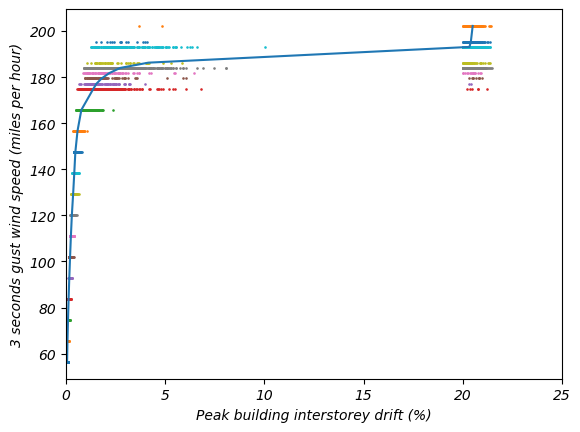

In [6]:
fig,ax = plt.subplots(1,1)

medians = simulation_results.median()
av_x = []
av_y = []

for col in simulation_results.columns : 
    y = np.full([simulation_results[col].shape[0],1],col)
    x = simulation_results[col].to_numpy()
    
    ax.scatter(x,y, s = 0.75)
    
    av_x.append(medians[col])
    av_y.append(col)
    
ax.plot(av_x,av_y)
ax.set_xlim([0,25])
ax.set_ylabel('3 seconds gust wind speed (miles per hour)')
ax.set_xlabel('Peak building interstorey drift (%)')

### Batch process the number of collapses at each wind speed : 

In [10]:
Collapse_limit = 0.2

MSA_dict = {}

sorted_sims = sorted(raw_simulation_results.keys())
sim_arrays = []


for i,sim in enumerate(sorted_sims) : 
    PID_data = raw_simulation_results[sim]
    
    # Isolate PID columns : 
    PIDs = PID_data.filter(regex="PID").to_numpy()
    mean_PID = PIDs.mean(axis=0)    
    

    Collapse_data = PID_data[(PID_data > Collapse_limit).any(axis=1)]*100

    print(f'IM : {sim} leads to {Collapse_data.shape[0]} collapses out of {PID_data.shape[0]} simulations.')
    
    MSA_dict[sim] = Collapse_data.shape[0]/PID_data.shape[0]
    
    sim_arrays.append((sim,Collapse_data.shape[0],PID_data.shape[0],Collapse_data.shape[0]/PID_data.shape[0]))
    
sim_arrays = np.array(sim_arrays)    
MSA_df = pd.DataFrame.from_dict(MSA_dict, orient = 'index', columns = ['Collapse ratios'])
display(MSA_df)

IM : 56.38094567407204 leads to 0 collapses out of 1000 simulations.
IM : 65.49786454902836 leads to 0 collapses out of 1000 simulations.
IM : 74.6147834239847 leads to 0 collapses out of 1000 simulations.
IM : 83.73170229894103 leads to 0 collapses out of 1000 simulations.
IM : 92.84862117389737 leads to 0 collapses out of 1000 simulations.
IM : 101.9655400488537 leads to 0 collapses out of 1000 simulations.
IM : 111.08245892381 leads to 0 collapses out of 1000 simulations.
IM : 120.1993777987663 leads to 0 collapses out of 1000 simulations.
IM : 129.3162966737227 leads to 0 collapses out of 1000 simulations.
IM : 138.433215548679 leads to 0 collapses out of 1000 simulations.
IM : 147.5501344236353 leads to 0 collapses out of 1000 simulations.
IM : 156.6670532985917 leads to 0 collapses out of 1000 simulations.
IM : 165.783972173548 leads to 0 collapses out of 1000 simulations.
IM : 174.9008910485043 leads to 6 collapses out of 1015 simulations.
IM : 177.180120767244 leads to 3 collap

,Collapse ratios
56.380946,0.000000
65.497865,0.000000
74.614783,0.000000
83.731702,0.000000
92.848621,0.000000
101.965540,0.000000
111.082459,0.000000
120.199378,0.000000
129.316297,0.000000
138.433216,0.000000


## Fragility curve fitting

In [11]:
x_guess = [185,0.05]

In [12]:
def loglikelyhood(x_guess,sim_data = sim_arrays) :
    
    # Penalize hard if the guess is an invalid dispersion (i.e. negative) : 
    if x_guess[1] < 0 : 
        log_likelihood = 1e10
    
    else : 
        # Get probabilities from binomial distribution, given the x_guess at each IM : 
        log_IMs = np.log(sim_arrays[:,0])
        probs = scipy.stats.norm.cdf(np.log(sim_data[:,0]),np.log(x_guess[0]),x_guess[1])

        # Get the likelihood estimates that the x_guess give the best approximations :
        probs = np.where(np.isclose(probs,0,atol = 1e-200),0,probs)

        
        likelihood = scipy.stats.binom.pmf(sim_data[:,1],sim_data[:,2],probs)
        likelihood = np.where(likelihood == 0 ,np.nextafter(0, 1),likelihood)

        # Get the total error between the guessed function and the existing data points :
        log_likelihood = (np.log(likelihood)).sum()*-1 ### The optimization function will aim to MINIMIZE the function

    return log_likelihood

curve_params = scipy.optimize.minimize(loglikelyhood,x_guess, args = sim_arrays, options = {'maxiter':1000})
print(curve_params.x)

[1.87983174e+02 3.33567000e-02]


Text(0, 0.5, 'Cumulative collapse probability')

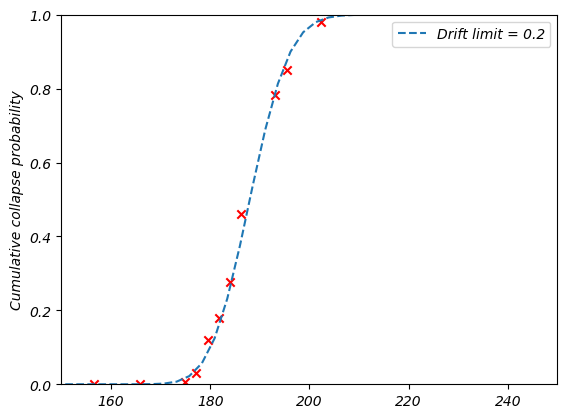

In [13]:
# Plot the fragility curve : 

sim_edges = (sim_arrays[:,0].min(),sim_arrays[:,0].max())

fitted_x = np.linspace(sim_edges[0]*0.9,sim_edges[1]*1.5,num=100)

fitted_y = scipy.stats.norm.cdf(np.log(fitted_x),np.log(curve_params.x[0]),curve_params.x[1])


plt.plot(fitted_x,fitted_y, linestyle = '--',label= f'Drift limit = {Collapse_limit}')
plt.scatter(MSA_df.index,MSA_df['Collapse ratios'], color = 'red',marker = 'x')
plt.legend()
plt.xlim([150,250])
plt.ylim([0,1])
plt.ylabel('Cumulative collapse probability')

In [14]:
# Get numbers for several drift limits : 

limits = [0.035,0.05,0.2]

sorted_sims = sorted(raw_simulation_results.keys())

limits_dict = {}



for lim in limits : 
    print(lim)    
    #MSA_dict = {}
    sim_arrays = []

    for i,sim in enumerate(sorted_sims) : 

        PID_data = raw_simulation_results[sim]

        # Isolate PID columns : 
        PIDs = PID_data.filter(regex="PID").to_numpy()
        mean_PID = PIDs.mean(axis=0)    

        Collapse_data = PID_data[(PID_data > lim).any(axis=1)]*100
        print(f'IM : {sim} leads to {Collapse_data.shape[0]} collapses out of {PID_data.shape[0]} simulations.')

        sim_arrays.append((sim,Collapse_data.shape[0],PID_data.shape[0],Collapse_data.shape[0]/PID_data.shape[0]))

    sim_arrays = np.array(sim_arrays)
    limits_dict[lim] = sim_arrays


0.035
IM : 56.38094567407204 leads to 0 collapses out of 1000 simulations.
IM : 65.49786454902836 leads to 0 collapses out of 1000 simulations.
IM : 74.6147834239847 leads to 0 collapses out of 1000 simulations.
IM : 83.73170229894103 leads to 0 collapses out of 1000 simulations.
IM : 92.84862117389737 leads to 0 collapses out of 1000 simulations.
IM : 101.9655400488537 leads to 0 collapses out of 1000 simulations.
IM : 111.08245892381 leads to 0 collapses out of 1000 simulations.
IM : 120.1993777987663 leads to 0 collapses out of 1000 simulations.
IM : 129.3162966737227 leads to 0 collapses out of 1000 simulations.
IM : 138.433215548679 leads to 0 collapses out of 1000 simulations.
IM : 147.5501344236353 leads to 0 collapses out of 1000 simulations.
IM : 156.6670532985917 leads to 0 collapses out of 1000 simulations.
IM : 165.783972173548 leads to 0 collapses out of 1000 simulations.
IM : 174.9008910485043 leads to 24 collapses out of 1015 simulations.
IM : 177.180120767244 leads to 4

In [15]:
limits_params = {}
saved_params = ''
for lim in limits :
    curve_params = scipy.optimize.minimize(loglikelyhood,x_guess, args = limits_dict[lim], options = {'maxiter':1000})
    limits_params[lim] = curve_params.x
limits_params

{0.035: array([1.86264275e+02, 3.41780061e-02]),
 0.05: array([1.87576785e+02, 3.39523760e-02]),
 0.2: array([1.87983174e+02, 3.33567000e-02])}

Text(0, 0.5, 'Conditional collapse probability')

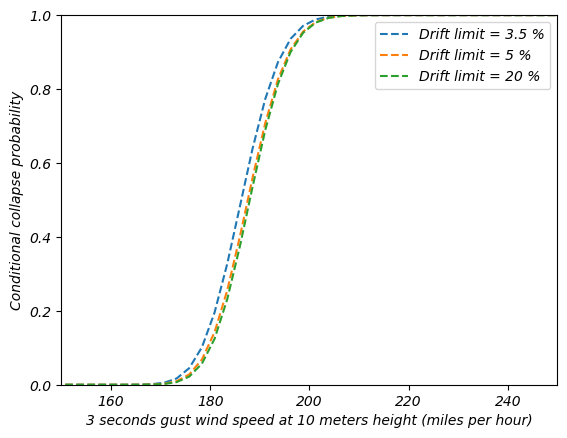

In [16]:
sim_edges = (sim_arrays[:,0].min(),sim_arrays[:,0].max())
fitted_x = np.linspace(sim_edges[0]*0.9,sim_edges[1]*1.5,num=100)


for i,j in enumerate(limits):
    params = limits_params[j]
    fitted_y = scipy.stats.norm.cdf(np.log(fitted_x),np.log(params[0]),params[1])
    
    display_j = j*100
    
    if int(display_j) == display_j :
        display_j = int(display_j)
    else : 
        display_j = f'{display_j:.1f}'
        
        
    plt.plot(fitted_x,fitted_y, linestyle = '--',label= f'Drift limit = {display_j} %')    
    #plt.plot(fitted_x,fitted_y, linestyle = '--',label= f'Drift limit = {(j*100):.1f} %')
    

plt.legend()
plt.xlim([150,250])
plt.ylim([0,1])
plt.xlabel('3 seconds gust wind speed at 10 meters height (miles per hour)')
plt.ylabel('Conditional collapse probability')    
  